# OpenBind-HIPPO

- **Target: A71EV2A**
- **Cycle: 01**

## Imports

In [1]:
%load_ext autoreload
%autoreload 2
import hippo
import mrich
from mrich import print
from pathlib import Path
from os import environ
import shutil
import molparse as mp
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

## Config

In [2]:
target_name = "A71EV2A"
target_dir = Path(environ["BULK"]) / "TARGETS" / target_name
cycle_name = "cycle_01"
cycle_dir = Path(cycle_name)
aligned_dir = target_dir / "aligned_files"

## Animal

In [3]:
animal = hippo.HIPPO(target_name, target_dir / f"{target_name}.sqlite")

 Creating HIPPO animal

name = A71EV2A

db_path = /opt/xchem-fragalysis-2/maxwin/BulkDock/TARGETS/A71EV2A/A71EV2A.sqlite

DEBUG: hippo.Database.__init__()

DEBUG: Database.path = /opt/xchem-fragalysis-2/maxwin/BulkDock/TARGETS/A71EV2A/A71EV2A.sqlite

DEBUG: hippo.Database.connect()

DEBUG: sqlite3.version='2.6.0'

 Success  Database connected @ /opt/xchem-fragalysis-2/maxwin/BulkDock/TARGETS/A71EV2A/A71EV2A.sqlite!

 Success  Initialised animal HIPPO("A71EV2A")!

## Queue BulkDock (re)placements

In [ ]:
scaffold_poses = animal.poses(tag="openbind_a71ev2a_c1_scaffolds_chemok_bbok")
elaborated_scaffolds = scaffold_poses.compounds.elabs.scaffolds
elaborated_scaffold_poses = animal.poses[set(elaborated_scaffolds.poses.ids).intersection(set(scaffold_poses.ids))]
elaborated_scaffold_poses

In [ ]:
data = []
for i,pose in enumerate(elaborated_scaffold_poses):
    print(i, pose)
    compound = pose.compound
    elabs = compound.elabs
    reference = pose.reference
    inspirations = pose.inspirations

    inspiration_d = dict()
    for i, name in enumerate(inspirations.names):
        inspiration_d[f"hit{i+1}"] = name
    
    for elab in mrich.track(elabs):
        d = dict(smiles=elab.smiles)
        d.update(inspiration_d)
        data.append(d)

df = pd.DataFrame(data)
df.to_csv("cycle_01/syndirella/elabs/a71ev2a_c1_elab_bulkdock_input.csv", index=False)
df

## Define chemspace

In [7]:
scaffolds = animal.compounds(tag="openbind_a71ev2a_c1_scaffolds_chemok_bbok")
scaffolds

compounds tagged openbind_a71ev2a_c1_scaffolds_chemok_bbok: {C × 558}

In [8]:
elabs = scaffolds.elabs
elabs

{C × 18454}

In [9]:
elaborated_scaffolds = elabs.scaffolds
elaborated_scaffolds

{C × 165}

In [10]:
# elab_poses = elabs.poses.filter(key="distance_score", value="2.0", operator="<=")
# elab_poses = elab_poses.filter(key="energy_score", value="0.0", operator="<=")
elab_poses = elabs.poses
elab_poses

{P × 36650}

In [11]:
posed_elabs = elab_poses.compounds
posed_elabs

{C × 17070}

In [ ]:
posed_elabs.add_tag("openbind_a71ev2a_c1_elabs")

In [ ]:
posed_elabs.scaffolds.add_tag("openbind_a71ev2a_c1_elaborated_scaffolds")

In [12]:
chemspace = posed_elabs + posed_elabs.scaffolds
chemspace

{C × 17229}

In [13]:
filtered_elab_poses = elabs.poses.filter(key="distance_score", value="2.0", operator="<=").filter(key="energy_score", value="0.0", operator="<=")
filtered_elab_poses.add_tag("openbind_a71ev2a_c1_elabs_filtered")
filtered_posed_elabs = filtered_elab_poses.compounds
filtered_posed_elabs.add_tag("openbind_a71ev2a_c1_elabs_filtered")
chemspace_filtered = filtered_posed_elabs + posed_elabs.scaffolds
chemspace_filtered

Tagged {P × 4859} w/ "openbind_a71ev2a_c1_elabs_filtered"

Tagged {C × 1942} w/ "openbind_a71ev2a_c1_elabs_filtered"

{C × 2101}

In [ ]:
pass_ids = set()
fail_ids = set()
for pose in mrich.track(animal.poses, total=animal.num_poses):
    mrich.set_progress_field("pass", len(pass_ids))
    try:
        ok = pose.posebusters()
    except Exception as e:
        mrich.error(pose, e)
        ok = False
        
    if ok:
        pass_ids.add(pose.id)
    else:
        fail_ids.add(pose.id)

## Export chemspace

In [ ]:
chemspace_poses = chemspace.best_placed_poses
chemspace_poses

In [ ]:
%%time
chemspace_poses.to_fragalysis("cycle_01/syndirella/elabs/openbind_a71ev2a_c1_elab_chemspace.sdf",
    method="openbind_a71ev2a_c1_elab_chemspace", 
    submitter_name="Max Winokan", 
    submitter_institution="DLS", 
    submitter_email="max.winokan@diamond.ac.uk",
    copy_reference_pdbs=True,
    metadata=False,
    tags=False,
    subsites=False,
)

In [ ]:
chemspace_filtered_poses = filtered_elab_poses.get_best_placed_poses_per_compound() + posed_elabs.scaffolds.best_placed_poses
chemspace_filtered_poses

In [ ]:
%%time
chemspace_filtered_poses.to_fragalysis("cycle_01/syndirella/elabs/openbind_a71ev2a_c1_elab_chemspace_filtered.sdf",
    method="openbind_a71ev2a_c1_elab_chemspace_filtered", 
    submitter_name="Max Winokan", 
    submitter_institution="DLS", 
    submitter_email="max.winokan@diamond.ac.uk",
    copy_reference_pdbs=True,
    metadata=False,
    tags=False,
    subsites=False,
)

In [ ]:
chemspace_filtered_poses[7].render()

## Full chemspace recipe

In [4]:
posed_chemspace = animal.compounds(tag="openbind_a71ev2a_c1_elabs_filtered")
posed_chemspace

compounds tagged openbind_a71ev2a_c1_elabs_filtered: {C × 1942}

In [5]:
recipe = hippo.Recipe.from_compounds(
    posed_chemspace,
    pick_first=True,
    pick_cheapest=False,
    quoted_only=True,
    use_routes=True
)
recipe

#compounds = 1942

Output()

Solving recipe combinations...

Output()

Recipe({Ingredient × 1467} --> {Ingredient × 1942} via {R × 1942})

In [6]:
recipe.write_json("cycle_01/rgen/openbind_a71ev2a_c1_elabs_filtered_recipe.json", price=False)

 DISK  Writing 
/opt/xchem-fragalysis-2/maxwin/openbind-hippo/a71ev2a/cycle_01/rgen/openbind_a71ev2a_c1_elabs_filtered_recipe.json.
..

ERROR! Session/line number was not unique in database. History logging moved to new session 935


In [7]:
recipe.write_reactant_csv("cycle_01/rgen/openbind_a71ev2a_c1_elabs_filtered_reactants.csv")

DEBUG: Querying database for routes

DEBUG: Assembling route dictionary

DEBUG: Checking availability

 DISK  Writing cycle_01/rgen/openbind_a71ev2a_c1_elabs_filtered_reactants.csv...

## Add in-stock reactants

In [ ]:
df = pd.read_csv("cycle_01/rgen/a71ev2a_c1_scaffolds_recipes/Recipe_1GB7RAD_reactants.csv")
df

In [ ]:
for i,row in df.iterrows():
    compound = animal.compounds[row["compound_id"]]
    quote = compound.add_stock(
        amount=row["quoted_amount_mg"],
        purity=row["quoted_purity"],
        entry=row["quote_entry"],
    )
    print(compound, quote)
    # break

In [ ]:
animal.C283111.get_quotes(df=True)

## Rgen

In [5]:
scaffold_chemsample_recipe = hippo.Recipe.from_json(animal.db, "cycle_01/rgen/a71ev2a_c1_scaffolds_recipes/Recipe_1GB7RAD.json")

 DISK  Reading cycle_01/rgen/a71ev2a_c1_scaffolds_recipes/Recipe_1GB7RAD.json...

Recipe was generated at: 2025-10-08 11:18:27.986227

reactants = {Ingredient × 182}

intermediates = {Ingredient × 0}

products = {Ingredient × 99}

reactions = {R × 99}

compounds = {Ingredient × 0}

In [14]:
# subtract planned synthesis cycle
product_pool = chemspace_filtered - scaffold_chemsample_recipe.product_compounds
product_pool

{C × 2078}

In [15]:
route_pool = hippo.RouteSet.from_product_ids(animal.db, product_pool.ids)
route_pool

Output()

{Route × 2079}

In [16]:
route_pool = route_pool.prune_unavailable(["Enamine", "Stock"])
route_pool

#routes before pruning = 2079

#routes after pruning = 2079

Output()

{Route × 2079}

### Start with cheapest analogues using existing reactants?

In [17]:
sql = f"""
SELECT route_id FROM quote
INNER JOIN reactant ON reactant_compound = quote_compound
INNER JOIN reaction ON reactant_reaction = reaction_id
INNER JOIN route ON route_product = reaction_product
WHERE quote_supplier = 'Stock'
AND route_product NOT IN {scaffold_chemsample_recipe.product_compounds.str_ids}
"""
c = animal.db.execute(sql)
cheap_routes = hippo.RouteSet.from_ids(animal.db, [i for i, in c])
cheap_routes = cheap_routes.prune_unavailable(["Enamine", "Stock"])
cheap_routes

Output()

#routes before pruning = 632

#routes after pruning = 578

Output()

{Route × 578}

In [18]:
route = list(cheap_routes.routes)[0]
route, route.price

(Route #42: C204781, €29.00 EUR)

In [19]:
data = []
for route in mrich.track(cheap_routes):
    data.append(dict(
        product_id=route.product.id, 
        route_id=route.id, 
        # chemistry=route.reactions.types[0], 
        price=route.price.amount
    ))
df = pd.DataFrame(data)
df

Output()

,product_id,route_id,price
0,204781,42,29.0
1,205067,45,84.7
2,266892,76,18.0
3,264727,77,19.0
4,48060,183,48.0
...,...,...,...
573,313509,19288,448.0
574,313542,19321,33.0
575,313560,19339,240.0
576,313590,19369,240.0


In [20]:
df.sort_values("price").head()

,product_id,route_id,price
99,6001,1223,18.0
97,7188,1170,18.0
94,1357,1158,18.0
90,13636,1130,18.0
34,45621,466,18.0


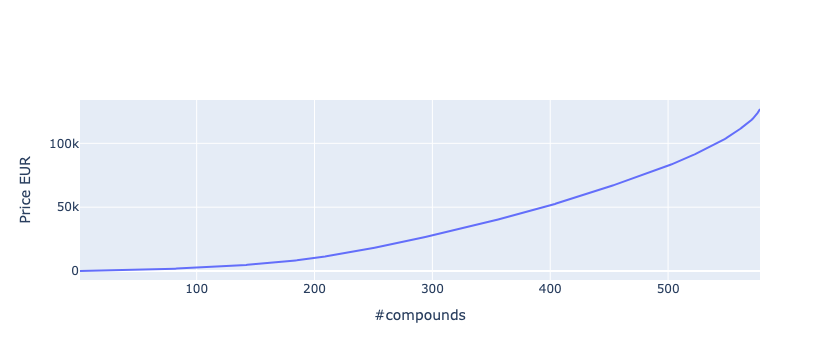

In [21]:
counts = []
prices = []
total = 0
for i,row in df.sort_values("price").iterrows():
    counts.append(len(counts)+1)
    total += row["price"]
    prices.append(total)

fig = go.Figure()
fig.add_trace(go.Scatter(x=counts, y=prices))
fig.update_layout(xaxis_title="#compounds", yaxis_title="Price EUR")

In [22]:
starting_recipes = hippo.Recipe.from_compounds(
    animal.compounds[list(df.sort_values("price").iloc[:100]["product_id"].unique())], 
    use_routes=True, 
    pick_cheapest=False,
)
starting_recipes

#compounds = 100

Output()

 Success  Found solution for compound=C1349!

 Success  Found solution for compound=C1357!

 Success  Found solution for compound=C1414!

...

 Success  Found solution for compound=C313482!

 Success  Found solution for compound=C313542!

Solving recipe combinations...

Output()

[Recipe({Ingredient × 137} --> {Ingredient × 100} via {R × 100})]

In [23]:
starting_recipe = starting_recipes[0]
starting_recipe.write_json("cycle_01/rgen/openbind_a71ev2a_c1_elabs_rgen_starting_recipe.json")

 DISK  Writing 
/opt/xchem-fragalysis-2/maxwin/openbind-hippo/a71ev2a/cycle_01/rgen/openbind_a71ev2a_c1_elabs_rgen_starting_recipe.
json...

In [24]:
starting_recipe.price

€2404.80 EUR

### Do the recipe generation

In [25]:
gen = hippo.RandomRecipeGenerator(
    db=animal.db, 
    start_with=starting_recipe, 
    suppliers=['Enamine', 'Stock'],
    route_pool=route_pool,
    out_key="cycle_01/rgen/a71ev2a_c1_elabs"
)

DEBUG: RandomRecipeGenerator.__init__()

database = /opt/xchem-fragalysis-2/maxwin/BulkDock/TARGETS/A71EV2A/A71EV2A.sqlite

max_lead_time = None

suppliers =
['Enamine', 'Stock']

out_key = cycle_01/rgen/a71ev2a_c1_elabs

 Warning  Will overwrite existing rgen data file: cycle_01/rgen/a71ev2a_c1_elabs_rgen.json!

#routes before pruning = 2079

#routes after pruning = 2079

Output()

 DISK  Writing cycle_01/rgen/a71ev2a_c1_elabs_rgen.json...

In [ ]:
recipe = gen.generate(balance_clusters=True, max_iter=1000)
recipe

In [ ]:
recipe.summary()

In [ ]:
recipe.reactants.price_df

In [ ]:
recipe = gen.generate(balance_clusters=False)
recipe

In [13]:
animal.elabs.poses.compounds.scaffolds

{C × 170}

## Export example series

In [6]:
elaborated_scaffolds = animal.compounds(tag="openbind_a71ev2a_c1_elaborated_scaffolds")

In [8]:
elaborated_scaffolds[0].elabs.poses.compounds

{C × 74}

In [11]:
elaborated_scaffolds[0]

C107 "ASAP-0031281-001"

In [12]:
elaborated_scaffolds[0].elabs.poses

{P × 203}

In [41]:
scaffold = animal.compounds["ASAP-0031281-001"]
poses = scaffold.poses + scaffold.elabs.poses
poses.to_fragalysis(
    f"cycle_01/syndirella/elabs/{scaffold.name}_elabs.sdf",
    method=f"{scaffold.name}_elabs",
    submitter_name="Max Winokan",
    submitter_institution="DLS",
    submitter_email="max.winokan@diamond.ac.uk",
)

DEBUG: 206 poses in set

DEBUG: 204 remaining after skipping null reference

DEBUG: 204 remaining after skipping null inspirations

#poses = 204

DEBUG: querying...

...

DEBUG: adding subsite column

out_path = 
/opt/xchem-fragalysis-2/maxwin/openbind-hippo/a71ev2a/cycle_01/syndirella/elabs/ASAP-0031281-001_elabs.sdf

[15:36:42] Molecule does not have explicit Hs. Consider calling AddHs()


 DISK  Writing 
/opt/xchem-fragalysis-2/maxwin/openbind-hippo/a71ev2a/cycle_01/syndirella/elabs/ASAP-0031281-001_elabs.sdf...

,HIPPO Pose ID,smiles,inchikey,alias,HIPPO Compound ID,ROMol,energy_score,distance_score,inspiration_score,Energy,...,fragmenstein_error,exports,GNINA pK,orig_smiles,tags,subsites,name,ref_mols,ref_pdb,_Name
0,45216,Cn1nc(C(=O)NCCc2cocn2)c2ccccc21,ONGQCMNCDUWDOR-UHFFFAOYSA-N,None,107,<rdkit.Chem.rdchem.Mol object at 0x7f2e85a85a80>,-27.234092,0.542984,None,73.960287,...,,[/opt/xchem-fragalysis-2/maxwin/BulkDock/OUTPU...,5.753,NaN,"fragmenstein_placed,BulkDock Fragalysis export...",1 - Active Site,P45216,"A2290a,A3436a",A2290a,P45216
1,56420,C[C@H](Cc1cocn1)NC(=O)c1nn(C)c2ccc(F)cc12,LLDZPHCJSJZSFN-UHFFFAOYSA-N,None,191887,<rdkit.Chem.rdchem.Mol object at 0x7f2e85a84d10>,13.542872,1.711796,None,99.979592,...,,[/opt/xchem-fragalysis-2/maxwin/openbind-hippo...,NaN,NaN,"fragmenstein_placed,openbind_a71ev2a_c1_fragme...",1 - Active Site,P56420,"A3510a,A4935a",A3510a,P56420
2,497883,Cc1ocnc1CCNC(=O)c1nn(C)c2ccc(F)cc12,SKWLCASPHPGKCF-UHFFFAOYSA-N,None,250891,<rdkit.Chem.rdchem.Mol object at 0x7f2e85a84130>,-21.210933,0.738298,None,NaN,...,NaN,[/opt/xchem-fragalysis-2/maxwin/openbind-hippo...,NaN,NaN,openbind_a71ev2a_c1_elabs_filtered,None,P497883,"A2290a,A3436a",A2290a,P497883
3,497884,Cc1nc(CCNC(=O)c2nn(C)c3ccc(F)cc23)co1,IIHQBSBEBQSMSZ-UHFFFAOYSA-N,None,289825,<rdkit.Chem.rdchem.Mol object at 0x7f2e85a84040>,-10.521861,0.533466,None,NaN,...,NaN,[/opt/xchem-fragalysis-2/maxwin/openbind-hippo...,NaN,NaN,openbind_a71ev2a_c1_elabs_filtered,None,P497884,"A2290a,A3436a",A2290a,P497884
4,497885,C[C@H](Cc1cocn1)NC(=O)c1nn(C)c2ccc(F)cc12,LLDZPHCJSJZSFN-SECBINFHSA-N,None,191887,<rdkit.Chem.rdchem.Mol object at 0x7f2e85a87b50>,-2.102867,0.710331,None,NaN,...,NaN,[/opt/xchem-fragalysis-2/maxwin/openbind-hippo...,NaN,NaN,openbind_a71ev2a_c1_elabs_filtered,None,P497885,"A2290a,A3436a",A2290a,P497885
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199,503519,COC(=O)C(Cc1cocn1)NC(=O)c1nn(CC2CNC(=O)O2)c2cc...,BMRKSVKHVNSEEK-UHFFFAOYSA-N,BMRKSVKHVNSEEK-UHFFFAOYSA-N-P183-P126-P183-601502,289894,<rdkit.Chem.rdchem.Mol object at 0x7f2e85862b60>,26.615833,1.319014,None,123.535359,...,,[/opt/xchem-fragalysis-2/maxwin/openbind-hippo...,NaN,COC(=O)C(Cc1cocn1)NC(=O)c1nn(CC2CNC(=O)O2)c2cc...,"fragmenstein_placed,a71ev2a_c1_elab_bulkdock_i...",None,BMRKSVKHVNSEEK-UHFFFAOYSA-N-P183-P126-P183-601502,"A2290a,A3436a",A0514a,BMRKSVKHVNSEEK-UHFFFAOYSA-N-P183-P126-P183-601502
200,503520,COC(=O)C(Cc1cocn1)NC(=O)c1nn(Cc2ccccc2)c2ccccc12,HTTSBEHOPRZHSA-UHFFFAOYSA-N,HTTSBEHOPRZHSA-UHFFFAOYSA-N-P126-P126-P183-601502,289895,<rdkit.Chem.rdchem.Mol object at 0x7f2e85862ca0>,-14.287370,1.945645,None,158.864274,...,,[/opt/xchem-fragalysis-2/maxwin/openbind-hippo...,NaN,COC(=O)C(Cc1cocn1)NC(=O)c1nn(Cc2ccccc2)c2ccccc12,"fragmenstein_placed,openbind_a71ev2a_c1_elabs_...",None,HTTSBEHOPRZHSA-UHFFFAOYSA-N-P126-P126-P183-601502,"A2290a,A3436a",A0514a,HTTSBEHOPRZHSA-UHFFFAOYSA-N-P126-P126-P183-601502
201,503521,COC(=O)C(Cc1cocn1)NC(=O)c1nn(Cc2ccccc2)c2ccccc12,HTTSBEHOPRZHSA-UHFFFAOYSA-N,HTTSBEHOPRZHSA-UHFFFAOYSA-N-P183-P126-P183-601502,289895,<rdkit.Chem.rdchem.Mol object at 0x7f2e85862fc0>,-9.979315,2.440847,None,163.172329,...,,[/opt/xchem-fragalysis-2/maxwin/openbind-hippo...,NaN,COC(=O)C(Cc1cocn1)NC(=O)c1nn(Cc2ccccc2)c2ccccc12,"fragmenstein_placed,a71ev2a_c1_elab_bulkdock_i...",None,HTTSBEHOPRZHSA-UHFFFAOYSA-N-P183-P126-P183-601502,"A2290a,A3436a",A0514a,HTTSBEHOPRZHSA-UHFFFAOYSA-N-P183-P126-P183-601502
202,503522,Cc1nc(CCNC(=O)c2nn(Cc3ccc(Cl)cc3Cl)c3ccccc23)c...,AKXUFMOJPOZWGY-UHFFFAOYSA-N,AKXUFMOJPOZWGY-UHFFFAOYSA-N-P126-P126-P183-601502,289896,<rdkit.Chem.rdchem.Mol object at 0x7f2e85862020>,21.514230,2.402301,None,138.449752,...,,[/opt/xchem-fragalysis-2/maxwin/openbind-hippo...,NaN,Cc1nc(CCNC(=O)c2nn(Cc3ccc(Cl)cc3Cl)c3ccccc23)c...,"fragmenstein_placed,a71ev2a_c1_elab_bulkdock_i...",None,AKXUFMOJPOZWGY-UHFFFAOYSA-N-P126-P126-P183-601502,"A2290a,A3436a",A0514a,AKXUFMOJPOZWGY-UHFFFAOYSA-N-P126-P126-P183-601502


In [38]:
df = poses.get_df()

DEBUG: querying...

Output()

 ERROR  None in smiles/inchikey column!

Output()

In [23]:
animal.compounds(smiles="Cn1nc(C(=O)NCCc2cocn2)c2ccccc21")

C107 "ASAP-0031281-001"

In [26]:
animal.P497883.smiles

'Cc1ocnc1CCNC(=O)c1nn(C)c2ccc(F)cc12'

In [39]:
df["smiles"].isna().any()

False

In [40]:
animal.C107.poses.names

['A2846a', 'ONGQCMNCDUWDOR-UHFFFAOYSA-N', 'ONGQCMNCDUWDOR-UHFFFAOYSA-N']